# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Es la continuación de la Tarea 1, por lo que se utilizarán los mismos datos y se puede reutilizar cualquier parte del código de dicha tarea.

Puede copiar este notebook en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y las librerías Pandas y scikit-learn. Para esta tarea se recomienda consultar la sección [Extracting features from text files](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html) de la documentación oficial de scikit-learn.

Recuerde que **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook.

In [38]:
from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
    classification_report,
)

from sklearn.preprocessing import LabelEncoder




## Descarga del dataset
Se utilizan los mismos datos que en la Tarea 1. Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas.

In [27]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train", cache_dir="../data")
df = ds.to_pandas()

# Parte 1: Dataset y representación numérica de texto

## 1. Preparación del dataset
Se utilizará un conjunto de datos reducido de los **tres medios de prensa con mayor cantidad de artículos**.
Se espera que utilice su propia versión de la función `clean_text()` de la Tarea 1.

Particione los datos para generar un conjunto de test del 30% del total, utilizando muestreo estratificado.

**Sugerencia**: utilice el parámetro `stratify` de la función `train_test_split` de scikit-learn y fije también el valor de `random_state` para obtener resultados reproducibles.

In [28]:
def clean_text(df, column_name):

    result = df[column_name].astype("string")

    # eliminar encabezado
    result = result.str.replace(r"^[^\n]*\n", "", regex=True)

    # minúsculas
    result = result.str.lower()

    # eliminar todo lo que no sea letra, número o espacio
    result = result.str.replace(r'[^a-z0-9\s]', ' ', regex=True)

    # normalizar espacios
    result = result.str.replace(r'\s+', ' ', regex=True).str.strip()

    return result


from sklearn.model_selection import train_test_split

top_3_publications = df['publication'].value_counts().head(3).index
df_top_3 = df[df['publication'].isin(top_3_publications)].copy()

df_top_3['CleanText'] = clean_text(df_top_3, 'article')

X = df_top_3['CleanText']
y = df_top_3['publication']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)


## 2. Verificación del balance de clases
Genere una visualización que permita verificar que el balance de artículos de cada medio es similar en train y test.

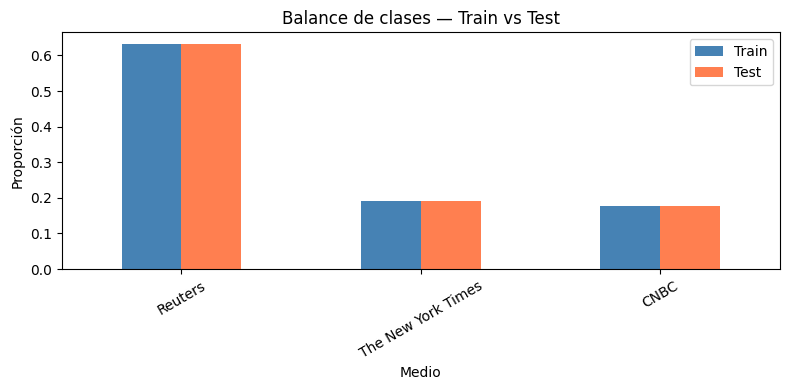

In [ ]:

balance = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True),
    'Test': y_test.value_counts(normalize=True)
})

balance.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'coral'])
plt.title('Balance de clases — Train vs Test')
plt.xlabel('Medio')
plt.ylabel('Proporción')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Representación Bag of Words
Transforme el texto del conjunto de entrenamiento a una representación numérica (features) de conteo de palabras (*bag of words*).
Explique brevemente cómo funciona esta técnica y muestre un ejemplo.
En particular, explique el tamaño de la matriz resultante y la razón por la que es una matriz *sparse*.

**Sugerencia**: puede ser útil imaginar qué sucedería con la memoria RAM requerida si no estuviéramos trabajando con un conjunto de datos reducido.

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train.fillna(""))
X_test_bow = vectorizer.transform(X_test.fillna(""))

print(f"Tamaño matriz train: {X_train_bow.shape}")
print(f"Valores no nulos: {X_train_bow.nnz}")
print(f"Densidad: {X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.4f}")

Tamaño matriz train: (10425, 86437)
Valores no nulos: 2207216
Densidad: 0.0024


Bag of Words convierte cada artículo en un vector de conteos: cada posición representa una palabra del vocabulario y el valor indica cuántas veces aparece en ese artículo.

Ejemplo con tres documentos:

| | "the" | "market" | "trump" | "family" |
|---|---|---|---|---|
| doc1 | 2 | 3 | 0 | 0 |
| doc2 | 1 | 0 | 4 | 0 |
| doc3 | 0 | 0 | 0 | 2 |

**Tamaño de la matriz:** `n_articulos × n_palabras_vocabulario`. Si hay 10.000 artículos y 80.000 palabras únicas, la matriz tiene 800 millones de celdas.

**Por qué es sparse:** cada artículo usa apenas una fracción mínima del vocabulario total, por lo que la mayoría de las celdas son cero. Guardar solo los valores no nulos reduce el uso de memoria drásticamente. Sin el dataset reducido, el vocabulario y la cantidad de artículos serían mucho mayores y la matriz densa no cabría en RAM.


## 4. Representación TF-IDF
Explique brevemente qué es un **n-grama**.
Obtenga la representación numérica *Term Frequency - Inverse Document Frequency* (TF-IDF).
Explique brevemente en qué consiste esta transformación adicional.

In [32]:

tfidf = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train.fillna(""))
X_test_tfidf = tfidf.transform(X_test.fillna(""))

print(f"Tamaño matriz train: {X_train_tfidf.shape}")


Tamaño matriz train: (10425, 1476817)


N-grama es una secuencia contigua de n palabras. Por ejemplo, para la frase "the new york times": unigramas serían ["the", "new", "york", "times"], bigramas ["the new", "new york", "york times"]. Usar bigramas o trigramas permite capturar frases con significado propio que se pierden tratando cada palabra de forma independiente.
TF-IDF pondera cada palabra por qué tan distintiva es: aumenta con la frecuencia en el documento (TF) pero decrece si aparece en muchos documentos (IDF). Así palabras comunes como "the" o "said" que aparecen en todos los artículos quedan con peso bajo, mientras que términos específicos de un medio o tema quedan con peso alto.

## 5. Visualización PCA sobre TF-IDF
Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de TF-IDF.
Analice los resultados y compare qué sucede si utiliza:
- a) el filtrado de `stop_words` para idioma inglés;
- b) el parámetro `use_idf=True`;
- c) `ngram_range=(1,2)`.

Opcionalmente, también puede analizar qué sucede si no elimina los signos de puntuación.

¿Se pueden separar los medios de prensa utilizando sólo 2 componentes principales?
Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (por ejemplo, hasta 10 componentes).

Discuta además si la separación observada puede deberse a diferencias de estilo editorial, a diferencias temáticas o a pistas explícitas del medio que no hayan sido removidas en la limpieza.

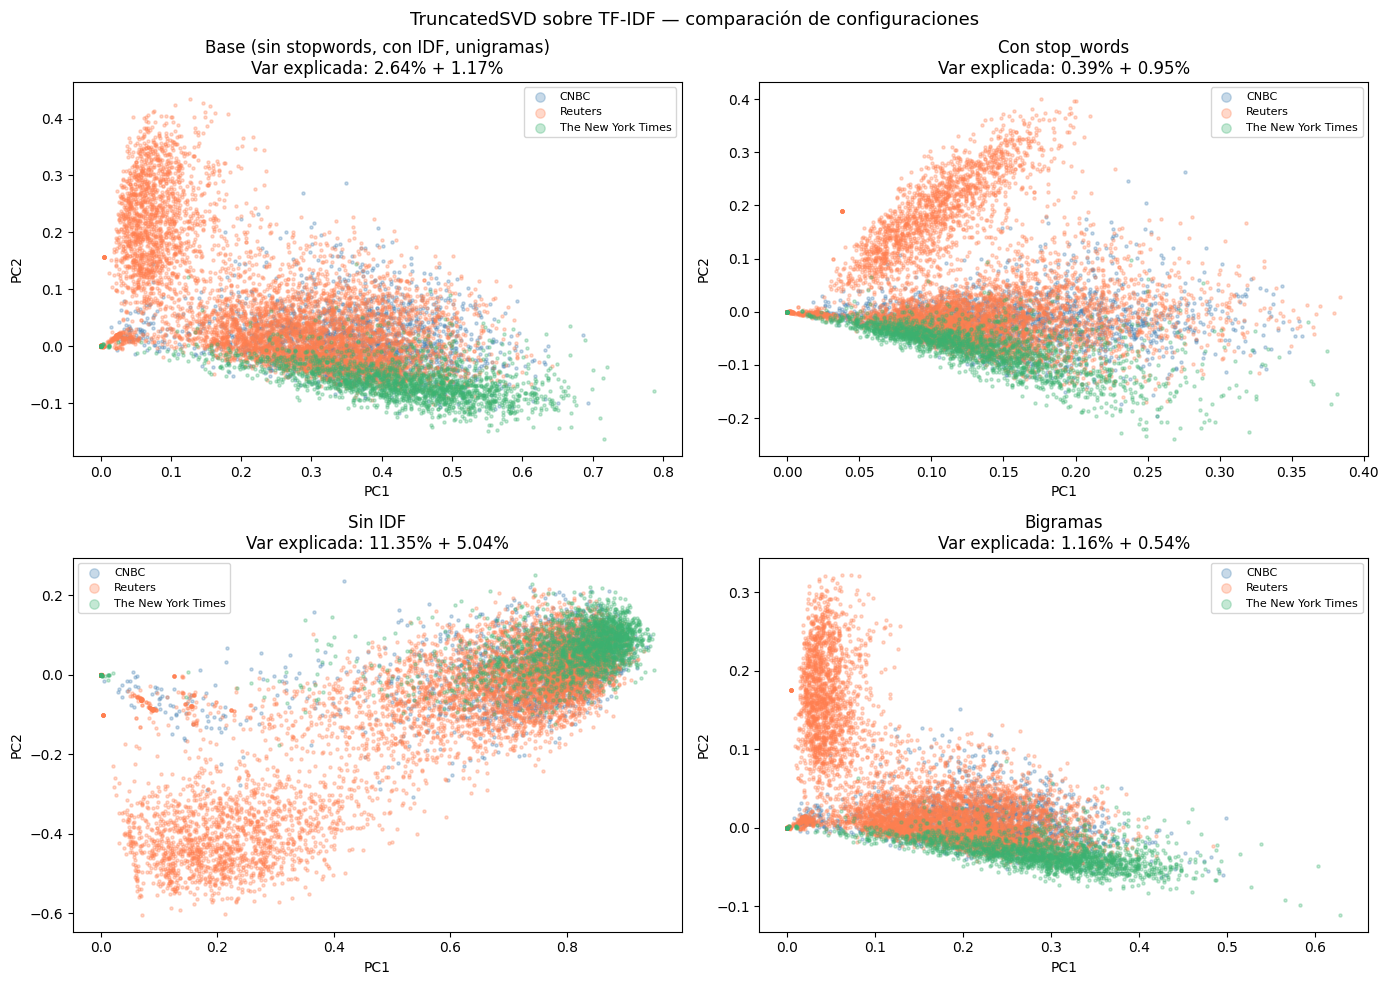

In [35]:


le = LabelEncoder()
y_encoded = le.fit_transform(y_train)
colors = ['steelblue', 'coral', 'mediumseagreen']

configs = {
    'Base (sin stopwords, con IDF, unigramas)': TfidfVectorizer(),
    'Con stop_words': TfidfVectorizer(stop_words='english'),
    'Sin IDF': TfidfVectorizer(use_idf=False),
    'Bigramas': TfidfVectorizer(ngram_range=(1, 2)),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, vec) in zip(axes.flatten(), configs.items()):
    X_vec = vec.fit_transform(X_train.fillna(""))
    svd = TruncatedSVD(n_components=2, random_state=42)
    X_red = svd.fit_transform(X_vec)
    var = svd.explained_variance_ratio_

    for i, label in enumerate(le.classes_):
        mask = y_encoded == i
        ax.scatter(X_red[mask, 0], X_red[mask, 1],
                   label=label, alpha=0.3, s=5, color=colors[i])

    ax.set_title(f'{title}\nVar explicada: {var[0]:.2%} + {var[1]:.2%}')
    ax.legend(markerscale=3, fontsize=8)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('TruncatedSVD sobre TF-IDF — comparación de configuraciones', fontsize=13)
plt.tight_layout()
plt.show()


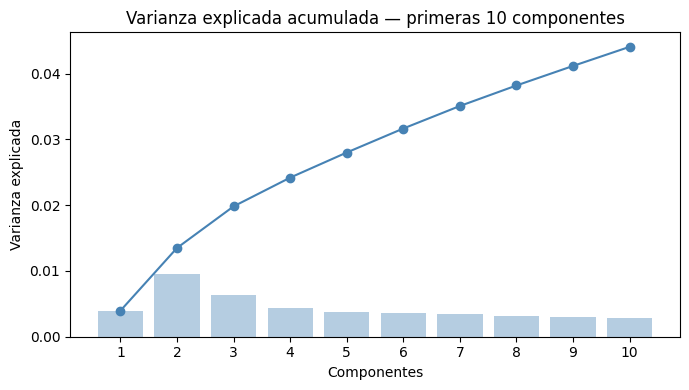

In [36]:
# Varianza explicada acumulada — primeras 10 componentes

tfidf_base = TfidfVectorizer(stop_words='english')
X_base = tfidf_base.fit_transform(X_train.fillna(""))

svd10 = TruncatedSVD(n_components=10, random_state=42)
svd10.fit(X_base)
cumvar = np.cumsum(svd10.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), cumvar, marker='o', color='steelblue')
plt.bar(range(1, 11), svd10.explained_variance_ratio_, alpha=0.4, color='steelblue')
plt.xlabel('Componentes')
plt.ylabel('Varianza explicada')
plt.title('Varianza explicada acumulada — primeras 10 componentes')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


# Parte 2: Entrenamiento y Evaluación de Modelos

## 1. Multinomial Naive Bayes
Entrene el modelo *Multinomial Naive Bayes* para clasificar los artículos según a qué medio de prensa pertenece el texto.
Utilice dicho modelo para clasificar los artículos del conjunto de test, y reporte el valor de *accuracy* y la **matriz de confusión**.
Reporte además el valor de *precision* y *recall* para cada medio.
Explique cómo se relacionan estos valores con la matriz anterior.

¿Qué problemas puede tener el hecho de mirar solamente el valor de *accuracy*?
Considere qué sucedería con esta métrica si el desbalance de datos fuera aún mayor entre medios.

**Sugerencia**: utilice el método `from_predictions` de `ConfusionMatrixDisplay` para realizar la matriz.

Accuracy: 0.6556
CNBC                      precision: 1.000  recall: 0.006
Reuters                   precision: 0.648  recall: 1.000
The New York Times        precision: 1.000  recall: 0.112


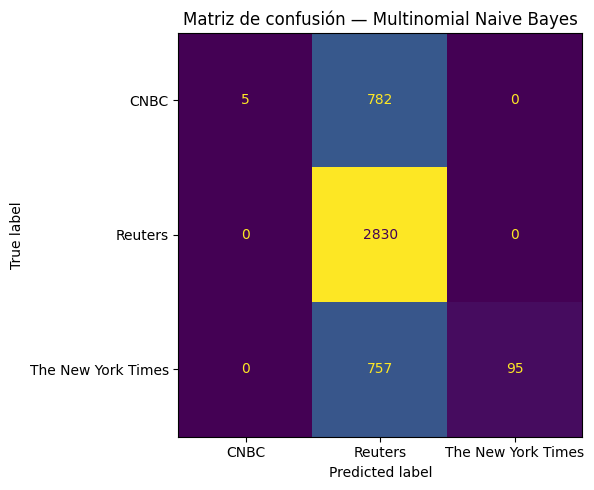

In [39]:


# Entrenar sobre X_train_tfidf
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Predecir sobre X_test_tfidf
y_pred = nb.predict(X_test_tfidf)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Precision y recall por medio
medios = le.classes_
for medio, p, r in zip(
    medios,
    precision_score(y_test, y_pred, average=None, labels=medios),
    recall_score(y_test, y_pred, average=None, labels=medios)
):
    print(f"{medio:25s} precision: {p:.3f}  recall: {r:.3f}")

# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
plt.title('Matriz de confusión — Multinomial Naive Bayes')
plt.tight_layout()
plt.show()


## 2. Validación cruzada y búsqueda de hiperparámetros
Explique cómo funciona la técnica de **validación cruzada** (*cross-validation*).
Implemente una búsqueda de hiperparámetros usando `GridSearchCV`.
Genere una visualización que permita comparar las métricas (por ejemplo, *accuracy*) de los distintos modelos entrenados, viendo el valor promedio y la variabilidad de las mismas en todos los *splits* (por ejemplo, en un gráfico de violín).

Mejor combinación: {'nb__alpha': 0.1, 'tfidf__ngram_range': (1, 1), 'tfidf__use_idf': False}
Mejor accuracy CV: 0.8148


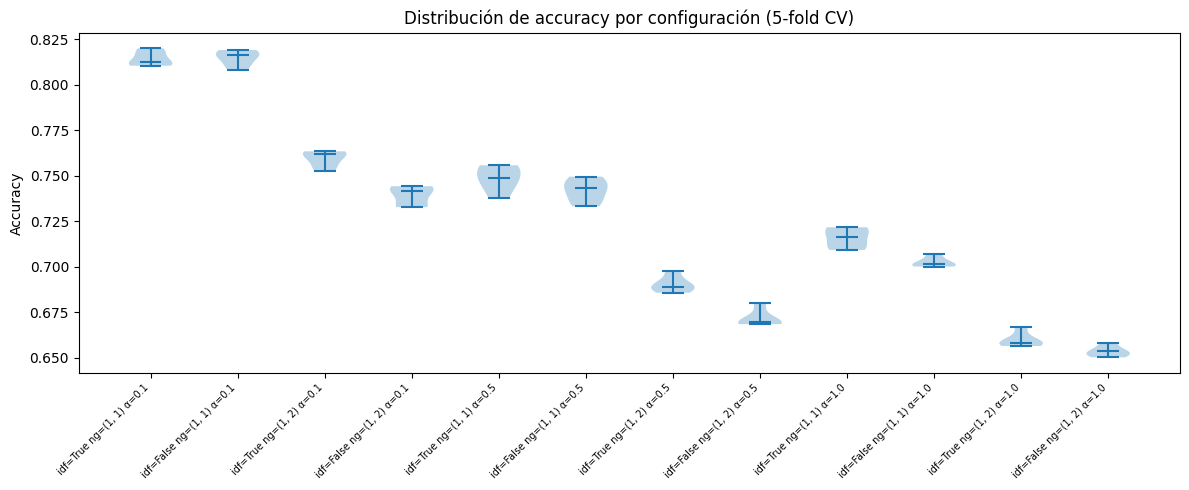

In [40]:
# TODO: Defina la grilla de hiperparámetros y ejecute GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb', MultinomialNB())
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__use_idf': [True, False],
    'nb__alpha': [0.1, 0.5, 1.0],
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train.fillna(""), y_train)

print(f"Mejor combinación: {grid.best_params_}")
print(f"Mejor accuracy CV: {grid.best_score_:.4f}")

results = pd.DataFrame(grid.cv_results_)

# armar un score por split para cada combinación
split_cols = [c for c in results.columns if c.startswith('split') and 'test_score' in c]
scores_matrix = results[split_cols].values  # shape: (n_configs, n_splits)
labels = [
    f"idf={r['param_tfidf__use_idf']} ng={r['param_tfidf__ngram_range']} α={r['param_nb__alpha']}"
    for _, r in results.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.violinplot(scores_matrix.T, positions=range(len(labels)), showmedians=True)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Accuracy')
ax.set_title('Distribución de accuracy por configuración (5-fold CV)')
plt.tight_layout()
plt.show()

## 3. Entrenamiento final con el mejor modelo
Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación).
Reporte el valor final de las métricas y la matriz de confusión.
Discuta las limitaciones de utilizar un modelo basado en *bag of words* o TF-IDF para el análisis de texto.

Accuracy final: 0.8120

CNBC                      precision: 0.908  recall: 0.276
Reuters                   precision: 0.810  recall: 0.962
The New York Times        precision: 0.794  recall: 0.809


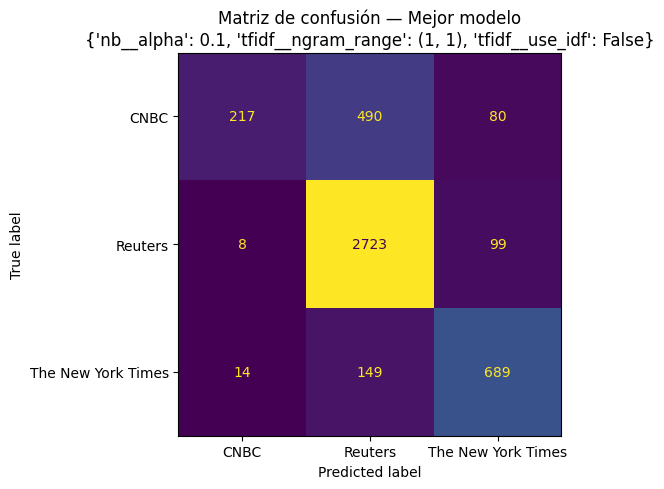

In [41]:
best = grid.best_estimator_
best.fit(X_train.fillna(""), y_train)
y_pred_final = best.predict(X_test.fillna(""))

print(f"Accuracy final: {accuracy_score(y_test, y_pred_final):.4f}\n")

medios = sorted(y_test.unique())
for medio, p, r in zip(
    medios,
    precision_score(y_test, y_pred_final, average=None, labels=medios),
    recall_score(y_test, y_pred_final, average=None, labels=medios)
):
    print(f"{medio:25s} precision: {p:.3f}  recall: {r:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=ax, colorbar=False)
plt.title(f'Matriz de confusión — Mejor modelo\n{grid.best_params_}')
plt.tight_layout()
plt.show()

## 4. Modelo alternativo
Evalúe al menos un modelo más (dentro de scikit-learn) aparte de *Multinomial Naive Bayes* para clasificar el texto utilizando las mismas *features* de texto.
Explique brevemente cómo funciona y compare los resultados con el anterior.

Accuracy Logistic Regression: 0.8998

CNBC                      precision: 0.864  recall: 0.624
Reuters                   precision: 0.895  recall: 0.981
The New York Times        precision: 0.945  recall: 0.884


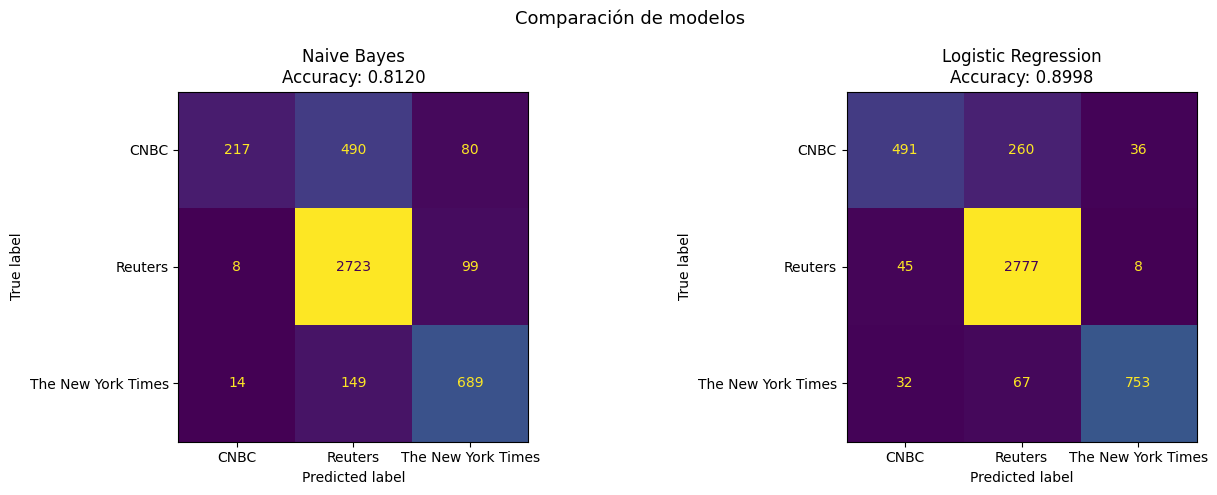

In [42]:
# TODO: Entrene al menos un modelo alternativo de scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay

# usar el mismo tfidf del mejor modelo anterior
tfidf_final = TfidfVectorizer(stop_words='english', **{
    k.replace('tfidf__', ''): v 
    for k, v in grid.best_params_.items() 
    if k.startswith('tfidf__')
})

X_train_lr = tfidf_final.fit_transform(X_train.fillna(""))
X_test_lr = tfidf_final.transform(X_test.fillna(""))

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_lr, y_train)
y_pred_lr = lr.predict(X_test_lr)

print(f"Accuracy Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}\n")

medios = sorted(y_test.unique())
for medio, p, r in zip(
    medios,
    precision_score(y_test, y_pred_lr, average=None, labels=medios),
    recall_score(y_test, y_pred_lr, average=None, labels=medios)
):
    print(f"{medio:25s} precision: {p:.3f}  recall: {r:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=axes[0], colorbar=False)
axes[0].set_title(f'Naive Bayes\nAccuracy: {accuracy_score(y_test, y_pred_final):.4f}')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[1], colorbar=False)
axes[1].set_title(f'Logistic Regression\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
plt.suptitle('Comparación de modelos', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Cambio de medio de prensa
Evalúe el problema cambiando al menos un medio de prensa.
En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.
Puede ser útil comentar acerca de técnicas como sobre-muestreo y submuestreo; no es necesario implementarlas.

Distribución de clases:
publication
Reuters               9431
The New York Times    2840
People                1528
Name: count, dtype: int64

Ratio max/min: 6.2x


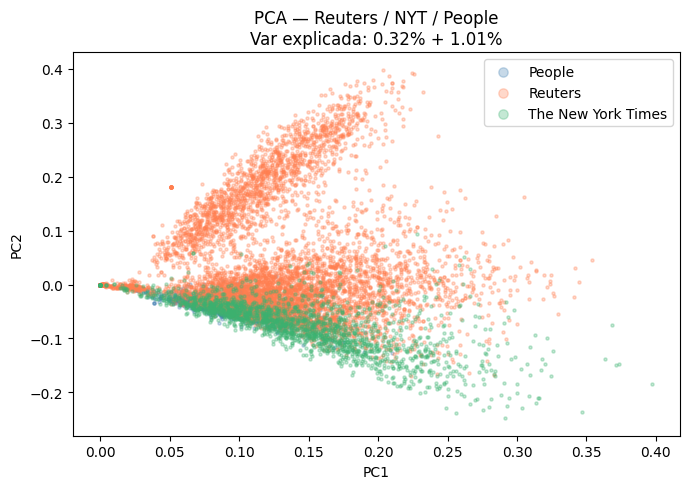

Accuracy: 0.9191

People                    precision: 0.959  recall: 0.771
Reuters                   precision: 0.946  recall: 0.971
The New York Times        precision: 0.813  recall: 0.825


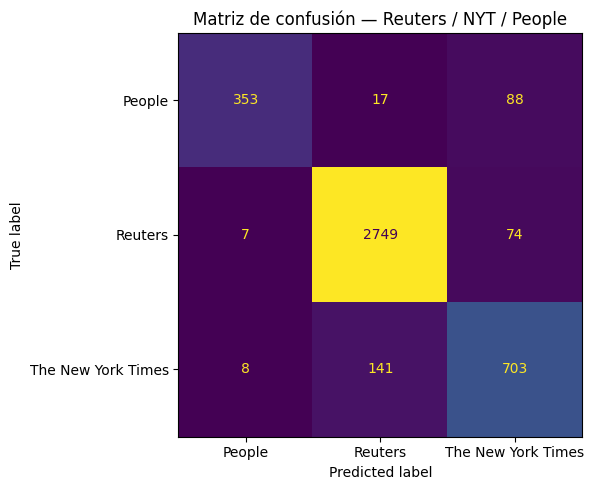

In [43]:
# TODO: Seleccione una combinación diferente de tres medios de prensa (cambiando al menos uno)
# y repita el proceso de entrenamiento y evaluación.

# Analice el balance de clases en este nuevo conjunto de datos
# ...

# reemplazar CNBC por People (más desbalanceado y temáticamente distinto)
otros_medios = ['Reuters', 'The New York Times', 'People']
df_alt = df[df['publication'].isin(otros_medios)].copy()
df_alt['CleanText'] = clean_text(df_alt, 'article')

print("Distribución de clases:")
print(df_alt['publication'].value_counts())
print(f"\nRatio max/min: {df_alt['publication'].value_counts().max() / df_alt['publication'].value_counts().min():.1f}x")

X_alt = df_alt['CleanText']
y_alt = df_alt['publication']

X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X_alt, y_alt, test_size=0.3, stratify=y_alt, random_state=42
)

# PCA con nuevo conjunto
tfidf_alt = TfidfVectorizer(stop_words='english')
X_alt_vec = tfidf_alt.fit_transform(X_train_alt.fillna(""))

svd_alt = TruncatedSVD(n_components=2, random_state=42)
X_alt_red = svd_alt.fit_transform(X_alt_vec)

le_alt = LabelEncoder()
y_alt_encoded = le_alt.fit_transform(y_train_alt)
colors = ['steelblue', 'coral', 'mediumseagreen']

plt.figure(figsize=(7, 5))
for i, label in enumerate(le_alt.classes_):
    mask = y_alt_encoded == i
    plt.scatter(X_alt_red[mask, 0], X_alt_red[mask, 1],
                label=label, alpha=0.3, s=5, color=colors[i])
plt.title(f'PCA — Reuters / NYT / People\nVar explicada: {svd_alt.explained_variance_ratio_[0]:.2%} + {svd_alt.explained_variance_ratio_[1]:.2%}')
plt.legend(markerscale=3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# entrenar y evaluar mejor pipeline sobre nuevo conjunto
pipeline_alt = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', **{
        k.replace('tfidf__', ''): v
        for k, v in grid.best_params_.items()
        if k.startswith('tfidf__')
    })),
    ('nb', MultinomialNB(alpha=grid.best_params_['nb__alpha']))
])

pipeline_alt.fit(X_train_alt.fillna(""), y_train_alt)
y_pred_alt = pipeline_alt.predict(X_test_alt.fillna(""))

print(f"Accuracy: {accuracy_score(y_test_alt, y_pred_alt):.4f}\n")
for medio, p, r in zip(
    le_alt.classes_,
    precision_score(y_test_alt, y_pred_alt, average=None, labels=le_alt.classes_),
    recall_score(y_test_alt, y_pred_alt, average=None, labels=le_alt.classes_)
):
    print(f"{medio:25s} precision: {p:.3f}  recall: {r:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test_alt, y_pred_alt, ax=ax, colorbar=False)
plt.title('Matriz de confusión — Reuters / NYT / People')
plt.tight_layout()
plt.show()

## 6. Técnica alternativa de extracción de features
Busque información sobre al menos una técnica alternativa de extraer *features* de texto.
Explique brevemente cómo funciona y qué tipo de diferencias esperaría en los resultados.
No se espera que implemente nada en esta parte.

Word Embeddings (Word2Vec, GloVe, FastText)
En lugar de representar cada palabra como una dimensión independiente, los embeddings la representan como un vector denso de dimensión fija (típicamente 100–300) entrenado para que palabras con contextos similares queden cerca en el espacio vectorial. "king" − "man" + "woman" ≈ "queen" es el ejemplo clásico. Para representar un artículo completo se suele promediar los vectores de sus palabras.
La diferencia clave respecto a TF-IDF es que captura similitud semántica: "car" y "automobile" quedan cerca, algo imposible en BoW. Sin embargo, el vector promedio pierde el orden de las palabras igual que BoW.
Embeddings contextuales (BERT, RoBERTa)
Son la evolución natural: en lugar de asignar un vector fijo a cada palabra, generan una representación que depende del contexto completo de la oración. La palabra "bank" tiene un vector distinto en "river bank" y "central bank". Se obtienen de modelos preentrenados en grandes corpus y se pueden afinar (fine-tune) para la tarea específica.
En este problema esperaría mejoras concretas en dos casos: artículos cortos donde TF-IDF tiene poco vocabulario para trabajar, y confusiones entre Reuters y CNBC que comparten vocabulario financiero pero tienen estilos distintos que un modelo contextual podría capturar mejor.
La desventaja es el costo computacional: BERT requiere GPU para tiempos razonables y el fine-tuning sobre el dataset completo de 5 medios tomaría horas, frente a segundos del pipeline TF-IDF + Naive Bayes.

## 7. Opcional: Clasificación a nivel de título
Repita la clasificación con los tres medios de prensa originales, pero esta vez clasificando a nivel de **título** en lugar de artículo completo.

Accuracy (título):   0.7360
Accuracy (artículo): 0.8120

CNBC                      precision: 0.623  recall: 0.287
Reuters                   precision: 0.748  recall: 0.929
The New York Times        precision: 0.733  recall: 0.509


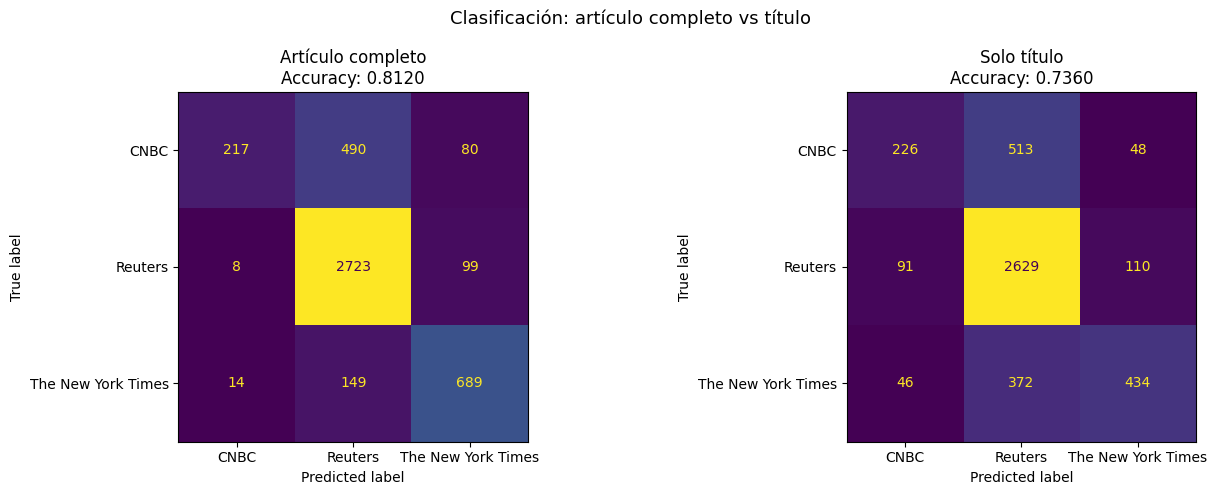

In [44]:
# Opcional: Repita el pipeline de clasificación utilizando el título del artículo
# en lugar del cuerpo del texto.

X_title = df_top_3['title']
y_title = df_top_3['publication']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_title, y_title, test_size=0.3, stratify=y_title, random_state=42
)

pipeline_title = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', **{
        k.replace('tfidf__', ''): v
        for k, v in grid.best_params_.items()
        if k.startswith('tfidf__')
    })),
    ('nb', MultinomialNB(alpha=grid.best_params_['nb__alpha']))
])

pipeline_title.fit(X_train_t.fillna(""), y_train_t)
y_pred_t = pipeline_title.predict(X_test_t.fillna(""))

print(f"Accuracy (título):   {accuracy_score(y_test_t, y_pred_t):.4f}")
print(f"Accuracy (artículo): {accuracy_score(y_test, y_pred_final):.4f}\n")

medios = sorted(y_test_t.unique())
for medio, p, r in zip(
    medios,
    precision_score(y_test_t, y_pred_t, average=None, labels=medios),
    recall_score(y_test_t, y_pred_t, average=None, labels=medios)
):
    print(f"{medio:25s} precision: {p:.3f}  recall: {r:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=axes[0], colorbar=False)
axes[0].set_title(f'Artículo completo\nAccuracy: {accuracy_score(y_test, y_pred_final):.4f}')
ConfusionMatrixDisplay.from_predictions(y_test_t, y_pred_t, ax=axes[1], colorbar=False)
axes[1].set_title(f'Solo título\nAccuracy: {accuracy_score(y_test_t, y_pred_t):.4f}')
plt.suptitle('Clasificación: artículo completo vs título', fontsize=13)
plt.tight_layout()
plt.show()